# Configuración Inicial

In [1]:
import sys
import os

def setup_workdirectory(
        repo_url="https://github.com/kikaymusic/EscuderoRodriguezSanchez.git",
        branch="dev",
        repo_name="EscuderoRodriguezSanchez",
        directoy_name="Entornos_Complejos"
):
    """
    Función para detectar si el código se está ejecutando en Google Colab o en local
    y configurar el entorno de trabajo en consecuencia.
    """
    # Detectamos si estamos en Google Colab
    in_colab = "google.colab" in sys.modules

    if in_colab:
        print("Entorno detectado: Google Colab")

        # Definimos la ruta del repositorio en Colab
        repo_path = f"/content/{repo_name}"

        # Borramos el repositorio si ya existe para evitar conflictos
        if os.path.exists(repo_path):
            os.system(f"rm -rf {repo_path}")

        # Clonamos la rama especificada del repositorio
        os.system(f"git clone -b {branch} --single-branch {repo_url}")

        # Cambiamos al directorio del repositorio
        os.system(f"%cd {repo_path}")

        # Añadimos el directorio especificado al path
        sys.path.append(f'/content/{repo_name}/{directoy_name}')

    else:
        print("Entorno detectado: Local")

        # Añadir el directorio especificado al path de Python
        notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
        k_brazos_dir = notebook_dir if directoy_name in notebook_dir else os.path.join(notebook_dir, directoy_name)
        if k_brazos_dir not in sys.path:
            sys.path.insert(0, k_brazos_dir)


setup_workdirectory()

Entorno detectado: Local


# Imports

✓ Usando versión con widgets (VS Code)


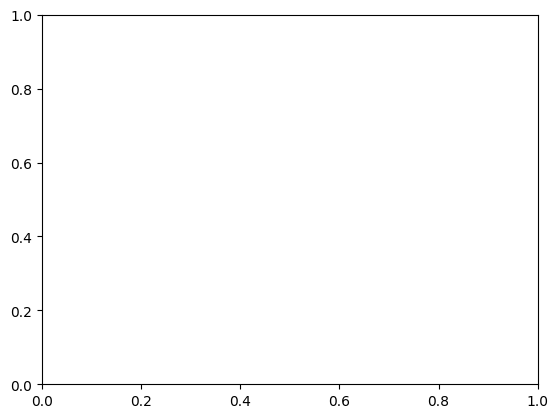

In [2]:
import gymnasium as gym
import torch
import numpy as np
import random
from src.train import train_agent
from src.utils import SEMILLA
from src.policies.epsilon_greedy import EpsilonGreedyPolicy
from src.features_extractors.tile import TileCodingExtractor
from src.utils import extract_v_and_policy_continuous
from src.agents import AgentSarsaSemiGradient
from src.agents.deep_qlearning import AgentDeepQLearning
from src.rnn.qnetwork import QNetwork
from src.plots import (
    plot_steps_per_episode,
    plot_cost_to_go,
    plot_policy_comparison
)

# Celda de imports - Añadir al final
try:
    # Intentar detectar si ipywidgets funciona correctamente
    import ipywidgets
    from src.evaluate_mountaincar_visual import evaluate_mountaincar_visual

    print("✓ Usando versión con widgets (VS Code)")
except:
    # Fallback para PyCharm
    from src.evaluate_mountaincar_visual_pycharm import evaluate_mountaincar_visual

    print("✓ Usando versión compatible con PyCharm")

# Asignamos la semilla para reproducibilidad
random.seed(SEMILLA)
os.environ['PYTHONHASHSEED'] = str(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.cuda.manual_seed(SEMILLA)
torch.cuda.manual_seed_all(SEMILLA)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Creamos el entorno de Mountain Car
env = gym.make("MountainCar-v0", render_mode="rgb_array", goal_velocity=0.0)

# Mountain Car con Agente SARSA Semi-Gradiente

Para este notebook, vamos a utilizar el entorno de mountain car, que es un entorno con un espacio de acciones continuo, que hace que no se pueda ejecutar con metodos tabulares. Vamos a empezar ejecutando el entorno con el agente SARSA semi-gradiente. Este algoritmo es On-Policy, por lo que la política de comportamiento y la objetivo serán la misma, y solo será necesario escoger una. La política elegida ha sido $\epsilon$-greedy, ya que tiene la suficiente exploración para que el algoritmo converja, y podrá explotar de mejor manera las opciones con mejor recompensa. Para el extractor de características, vamos a utilizar *tile coding extractor*, ya que es lo suficiente potente y es más eficiente que otros extractores de características.

In [3]:
alpha = 0.05
gamma = 1
epsilon = 0.01

# Inicializar el feature extractor optimizado
feature_extractor = TileCodingExtractor(env)
# Calcular número de características usando el extractor
test_state, _ = env.reset()
test_features = feature_extractor(test_state, 0)
n_features = len(test_features)

# Inicializamos la política con la semilla
policy = EpsilonGreedyPolicy(epsilon=epsilon, n_actions=env.action_space.n, seed=SEMILLA)  # Política

# El agente usa las políticas
agent_tile = AgentSarsaSemiGradient(
    env=env,
    policy=policy,
    feature_extractor=feature_extractor,
    n_features=n_features,
    alpha=alpha,
    gamma=gamma
)

# Antes de iniciar el entrenamiento, lo reiniciamos pasándole la semilla
state, info = env.reset(seed=SEMILLA)

In [4]:
print(env.observation_space)
print(env.action_space)

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Discrete(3)


## Visualización de juego pre-entrenamiento

In [5]:
results_before = evaluate_mountaincar_visual(
    env, agent_tile,
    n_episodes=5,
    seed_base=SEMILLA,
    delay=0
)

print(results_before)

{'successes': 0, 'failures': 5, 'success_rate': 0.0, 'avg_reward': np.float64(-200.0), 'avg_steps': np.float64(200.0)}


## Entrenamiento del Agente

In [6]:
episode_returns_tile, episode_lengths_tile = train_agent(
    env,
    agent_tile,
    n_episodes=5000,
    max_steps=200,
    print_freq=1000
)

Episode 1000/5000 - avg_return_last_1000=-131.3730
Episode 2000/5000 - avg_return_last_1000=-119.9380
Episode 3000/5000 - avg_return_last_1000=-121.7110
Episode 4000/5000 - avg_return_last_1000=-120.2180
Episode 5000/5000 - avg_return_last_1000=-116.6890


## Visualización Gráfica del juego

In [7]:
results_after_tile = evaluate_mountaincar_visual(
    env, agent_tile,
    n_episodes=5,
    seed_base=SEMILLA + 10000,
    delay=0
)
print(results_after_tile)

{'successes': 5, 'failures': 0, 'success_rate': 100.0, 'avg_reward': np.float64(-134.6), 'avg_steps': np.float64(134.6)}


# Mountain Car con Agente Deep Q Learning

Ahora vamos a ejecutar el entorno con el agente Deep Q-Learning. En este caso, solo tenemos que elegir la política de comportamiento, ya que en vez de política objetivo se usará una red neuronal. Como política usaremos $\epsilon$-greedy, ya que tiene la suficiente exploración para que el algoritmo converja, y podrá explotar de mejor manera las opciones con mejor recompensa. Para la red neuronal, vamos a utilizar un perceptrón multicapa con 2 capas ocultas de 128 neuronas, que es lo suficiente complejo para este entorno. En nuestra implementación, hemos añadido una optimización para que la red neuronal aprenda solo cada 4 acciones, mejorando el aprendizaje debido a la diversidad de los datos del Replay Buffer y reduciendo el tiempo de ejecución.

In [8]:
# Creamos la red neuronal para Deep Q-Learning
q_network = QNetwork(state_dim=2, action_dim=3, hidden_dim=128)

# Inicializamos la política de comportamiento
policy_dql = EpsilonGreedyPolicy(epsilon=0.1, n_actions=env.action_space.n, seed=SEMILLA)

# Creamos el agente Deep Q-Learning
agent_dql = AgentDeepQLearning(
    env=env,
    behavior_policy=policy_dql,
    q_network=q_network,
    lr=1e-3,
    buffer_size=20000,
    batch_size=64,
    update_frequency=4,
    gamma=0.99,
    seed=SEMILLA
)
print(f"Dispositivo donde ejecutar red neuronal de Deep Q-Learning: {agent_dql.device}")

# Reiniciamos el entorno con la semilla
state, info = env.reset(seed=SEMILLA)

Dispositivo donde ejecutar red neuronal de Deep Q-Learning: cpu


In [9]:
print(env.observation_space)
print(env.action_space)

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Discrete(3)


## Visualización de juego pre-entrenamiento

In [10]:
results_before_dql = evaluate_mountaincar_visual(
    env, agent_dql,
    n_episodes=5,
    seed_base=SEMILLA,
    delay=0
)
print(results_before_dql)

{'successes': 0, 'failures': 5, 'success_rate': 0.0, 'avg_reward': np.float64(-200.0), 'avg_steps': np.float64(200.0)}


## Entrenamiento del Agente

In [11]:
episode_returns_dql, episode_lengths_dql = train_agent(
    env,
    agent_dql,
    n_episodes=5000,
    max_steps=300,
    print_freq=1000
)

Episode 1000/5000 - avg_return_last_1000=-164.7230
Episode 2000/5000 - avg_return_last_1000=-152.8390
Episode 3000/5000 - avg_return_last_1000=-145.1690
Episode 4000/5000 - avg_return_last_1000=-136.6880
Episode 5000/5000 - avg_return_last_1000=-137.2630


## Visualización Gráfica del juego

In [12]:
results_after_dql = evaluate_mountaincar_visual(
    env, agent_dql,
    n_episodes=5,
    seed_base=SEMILLA + 10000,
    delay=0
)
print(results_after_dql)

{'successes': 1, 'failures': 4, 'success_rate': 20.0, 'avg_reward': np.float64(-182.4), 'avg_steps': np.float64(182.4)}


# Análisis de resultados y comparativa

### Número de pasos por episodio

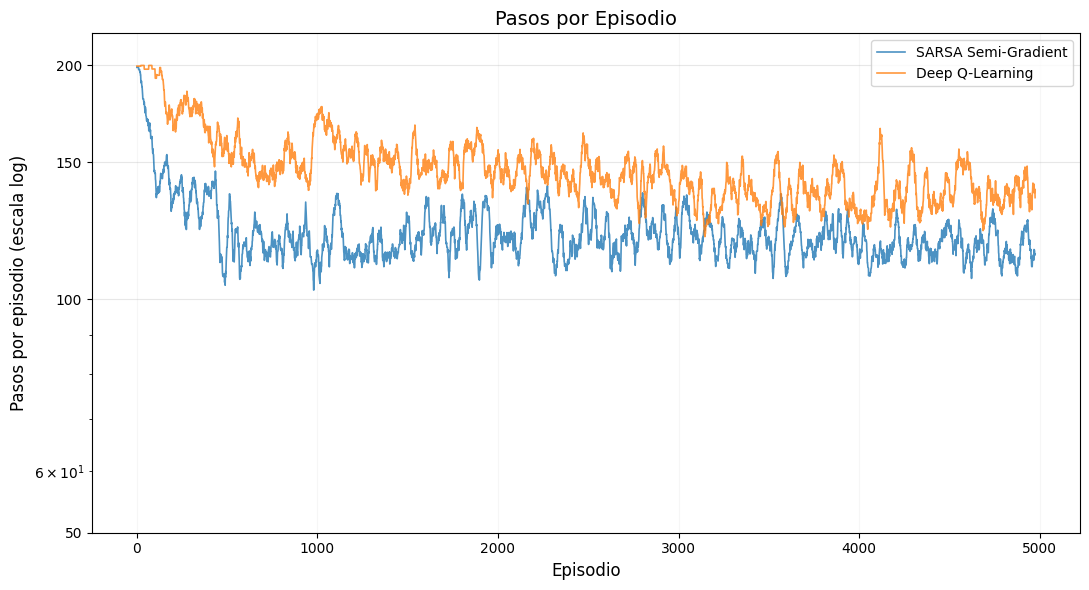

In [13]:
plot_steps_per_episode(
    [episode_lengths_tile, episode_lengths_dql], 
    ["SARSA Semi-Gradient", "Deep Q-Learning"],
    window=25
)

**Ejes de la gráfica**

- **Eje horizontal (Episodio)**: Representa el número del episodio, para ver la evolución a lo largo de todo el entrenamiento.
- **Eje vertical (Pasos por episodio)**: Representa el número de pasos que ha tardado el agente en terminar el episodio. Cuanto más bajo sea el valor, menos pasos habrá tardado el agente en terminar, por lo que habrá tardado menos tiempo.

Con esta gráfica, podremos ver que tan rápido han aprendido los agentes y como de eficientes son sus soluciones a lo largo del tiempo.

---

**SARSA semi-gradient**

- Presenta una caida drástica en el número de pasos casi de inmediato (primeros 500 pasos), por lo que el algoritmo ha conseguido encontrar rápidamente una estrategia balanceada que le consigue escalar la montaña.
- El agente se estabiliza en un rango entre 110 y 130 pasos por episodio, siendo bastante eficiente. Aunque podemos ver oscilaciones, en general la tendencia es bastante plana y consistente, sobre todo a partir del episodio 4000.

---

**Deep Q-Learning**

- Necesita aproximadamente 1000 episodios para empezar a converger, por lo que presenta una convergencia un poco lenta. El agente empieza a estabilizarse aproximadamente a partir de alcanzar los 140 pasos.
- Una vez ha convergido el agente, vemos que se encuentra en un rango de entre 125 y 150, aunque podemos ver que en general la gráfica tiene bastante variabilidad.

---

**Conclusiones**

- SARSA semi-gradiente es claramente superior a Deep Q-Learning en este caso, ya que consigue una convergencia más rápida y mejores resultados a lo largo de todos los episodios. Esto puede deberse a que SARSA es On-Policy, y además usa aproximadores lineales, por lo que puede generalizar de forma muy suave en espacios de estados continuos. DQL, al ser Off-Policy y usar redes neuronales, es un algoritmo más complejo que en problemas tan sencillos como este puede sufrir de overfitting o inestabilidad, lo que hace que el agente tome decisiones contradictorias en estados muy cercanos del espacio.

### Superficie de Valores de Estado

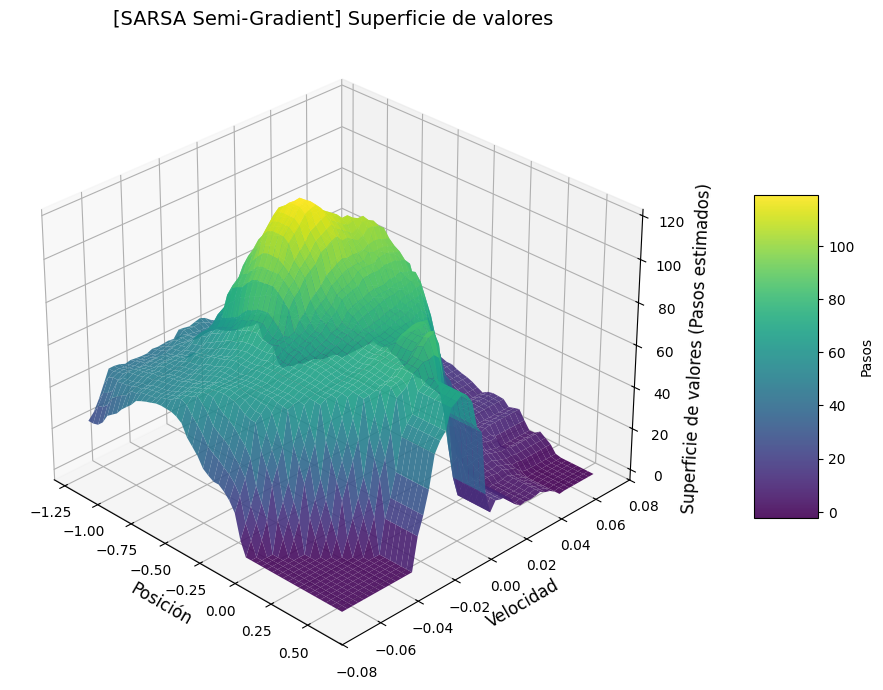

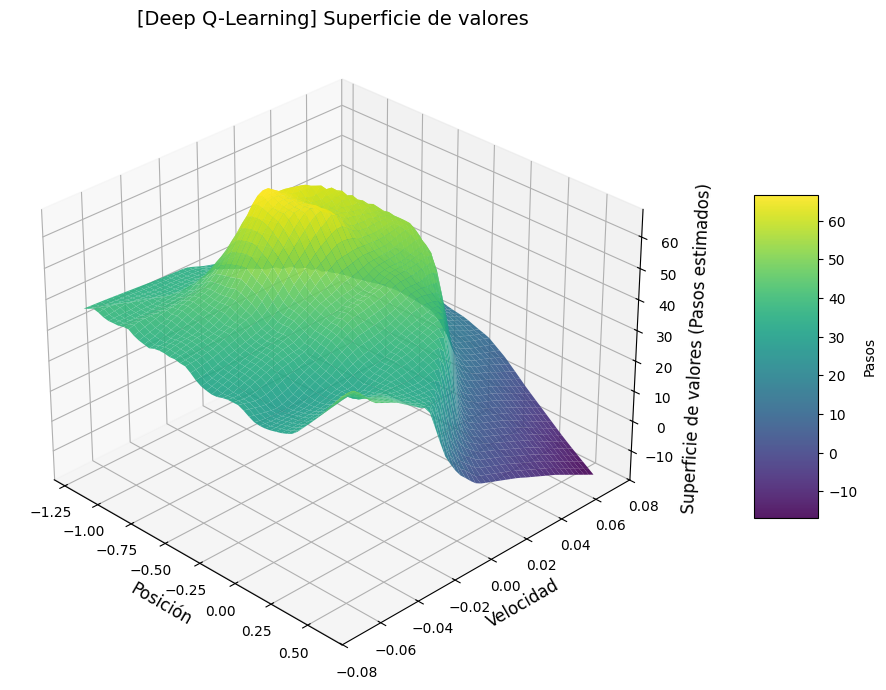

In [14]:
pos_ssg, vel_ssg, v_grid_ssg, policy_grid_ssg = extract_v_and_policy_continuous(env, agent_tile)
pos_dql, vel_dql, v_grid_dql, policy_grid_dql = extract_v_and_policy_continuous(env, agent_dql)

plot_cost_to_go(pos_ssg, vel_ssg, v_grid_ssg, agent_name="SARSA Semi-Gradient")
plot_cost_to_go(pos_dql, vel_dql, v_grid_dql, agent_name="Deep Q-Learning")

**Ejes de la gráfica**

- **Eje X (Posición)**: Representa la posición del agente.
- **Eje Y (Velocidad)**: Representa la velocidad del agente.
- **Eje Z (Superficie de valores)**: Representa los pasos estimados que tomará el agente hasta llegar al objetivo.

Con esta gráfica, podremos ver la estimación que toma el agente en cuanto a los pasos que necesitará para terminar el episodio según la posición y velocidad actuales. Los puntos más altos muestran estados donde el agente piensa que tardará mucho en alcanzar su objetivo.

---

**SARSA semi-gradient**

- El rango Z llega hasta los 120 pasos. Esto es coherente viendo los resultados de la gráfica anterior, ya que el agente terminaba los episodios con esa cantidad de pasos aproximadamente. Esto nos indica que la estimación del agente es muy realista.
- Las arrugas de la superficia indican que el algoritmo ha podido identificar con bastante precisión los puntos donde gana o pierde la inercia necesaria para poder subir la montaña. Esto puede deberse gracias a que el algoritmo es On-Policy y sus aproximadores lineales consiguen una estimación bastante precisa de cada estado.

---

**Deep Q-Learning**

- El rango Z llega solo hasta 60-70 pasos, y en la base podemos ver incluso valores negativos. Esto se debe a que el agente tiene un comportamiento demasiado optimista, y cree que puede terminar el episodio más rápido de lo que en realidad puede. Este comportamiento optimista es muy típico del algoritmo Q-Learning.
- La gráfica en general es muy suave, por lo que parece que la red neuronal no está consiguiendo distinguir entre estados similares pero con consecuencias distintas, eliminando detalles importantes de la gráfica.

---

**Conclusiones**

- SARSA, al ser On-Policy y más simple, está siendo un algoritmo más realista, que aprende basándose en lo que está haciendo cada paso y consigue crear un mapa de la montaña muy preciso. Mientras tanto, DQN se queda atrás por ser demasiado optimista, y además al usar una red neuronal en un problema tan sencillo, está simplificando demasiado el terreno, haciendo que las decisiones tomadas no sean las correctas y se tome más tiempo del necesario.


### Mapa de elecciones del agente

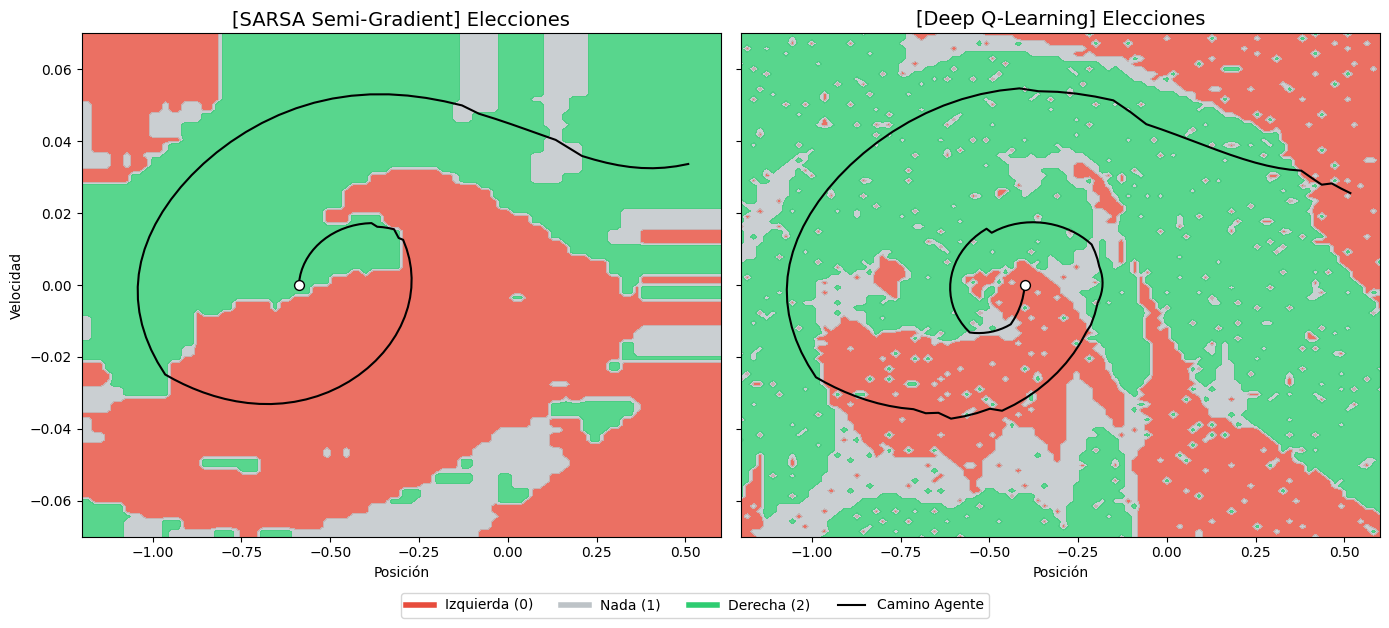

In [15]:
plot_policy_comparison(
    agents=[agent_tile, agent_dql], 
    labels=["SARSA Semi-Gradient", "Deep Q-Learning"], 
    env=env, 
    resolution=100
)

**Explicación de la gráfica**

- **Eje horizontal (Posición)**: Representa la posición del agente.
- **Eje vertical (Velocidad)**: Representa la velocidad del agente.
- **Linea negra (Camino agente)**: Representa el camino tomado por el agente hasta llegar al objetivo.
- **Región roja, gris y verde (Decisión del agente)**: Representa la decisión que tomaria el agente según su posición y velocidad actuales.

Con esta gráfica, podemos ver el camino que tomará el agente hasta llegar al objetivo, y las decisiones que tomaría según la posición y velocidad actuales.

---

**SARSA semi-gradient**

- Las areas de decisión del agente son bastante suaves y están bien delimitadas, por lo que el agente ha conseguido generalizar bien las regiones de éxito.
- El camino del agente es una espiral limpia, que nos muestra que el algoritmo tiende a ser más conservador y estable, debido a que actualiza su conocimiento basándose en la acción que realmente va a tomar.

---

**Deep Q-Learning**

- Las areas de decisión tienen bastante ruido, cosa que sucede debido a la inestabilidad de las redes neuronales profundas, y que al intentar maximizar el valor de Q de forma agresiva puede llegar a tomar cambios de decisión muy bruscos.
- Aunque el agente consigue llegar a la meta, a lo largo de todo el camino podemos observar pequeñas oscilaciones. Igual que como hemos visto con las areas de decisión, esto se debe al comportamiento de DQL que busca maximizar Q de forma agresiva, produciendo cambios de decisión muy bruscos ante variaciones mínimas en el estado.

---

**Conclusiones**

- SARSA ha conseguido una política muy coherente visualmente, en la que podemos ver perfectamente delimitadas las regiones en las que se toman cada una de las decisiones. DQL, aunque también consigue llegar a su objetivo, se ve una política más fragmentada que podría ser menos robusta ante variaciones leves de ruido.
- Ambas gráficas muestran como el agente debe "balancearse" para llegar al objetivo, tomando la decisión de ir hacia la derecha con velocidad positiva para seguir subiendo la colina, y yendo hacia la izquierda con velocidad negativa para coger carrerilla. Una diferencia clave que vemos entre ambos agentes es que SARSA empieza yendo hacia la derecha, cosa que hace que al volver a la izquierda consiga la suficiente carrerilla para subir la cuesta en la siguiente vez que vuelve a la derecha. Por otro lado, DQL empieza yendo a la izquierda, haciendo que consiga subir la colina, pero tardando más tiempo.
- SARSA semi-gradiente es un algoritmo más sencillo de estabilizar en problemas como este, mientras que DQL, al usar redes neuronales, no consigue adaptarse de forma tan buena al problema.